<a href="https://colab.research.google.com/github/m22aie202/FM_GenAI/blob/main/m22aie202_Assignment_1_Attempt_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [55]:
#Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import torchvision
from torchvision import transforms
from torchvision.utils import make_grid

import matplotlib.pyplot as plt
import numpy as np

In [56]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [57]:
#Loading dataset CIFAR-10
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

In [58]:
#Encoder
class Encoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),   # 16
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), # 8
            nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1),# 4
            nn.ReLU(),
        )

        self.flatten_dim = 256 * 4 * 4
        self.fc_mu = nn.Linear(self.flatten_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_dim, latent_dim)

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc_mu(x), self.fc_logvar(x)

In [59]:
#Reparameterization
def reparameterize(mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std

In [60]:
#decoder same as per encoder

class Decoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()

        self.fc = nn.Linear(latent_dim, 256 * 4 * 4)

        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),  # 8
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),   # 16
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),    # 32
            nn.ReLU(),
            nn.Conv2d(32, 3, 3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, 256, 4, 4)
        return self.deconv(x)

In [61]:
#now model load
class VAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = reparameterize(mu, logvar)
        recon = self.decoder(z)
        return recon, mu, logvar

In [62]:
#get the model
latent_dim = 256
model = VAE(latent_dim).to(device)


In [63]:
#loss function
def vae_loss(recon_x, x, mu, logvar, beta=1.0):
    recon_loss = F.mse_loss(recon_x, x, reduction="sum")
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + beta * kl, recon_loss, kl

In [64]:
#optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [65]:
epochs = 60
beta = 0.5

In [66]:
train_losses = []
recon_losses = []
kl_losses = []

In [67]:
#training model
for epoch in range(epochs):
    model.train()

    total_loss = 0
    total_recon = 0
    total_kl = 0

    for x, _ in train_loader:
        x = x.to(device)

        optimizer.zero_grad()

        recon, mu, logvar = model(x)

        loss, r_loss, kl = vae_loss(recon, x, mu, logvar, beta)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_recon += r_loss.item()
        total_kl += kl.item()

    avg_loss = total_loss / len(train_loader.dataset)
    avg_recon = total_recon / len(train_loader.dataset)
    avg_kl = total_kl / len(train_loader.dataset)

    train_losses.append(avg_loss)
    recon_losses.append(avg_recon)
    kl_losses.append(avg_kl)

    print(f"Epoch [{epoch+1}/{epochs}]  "
          f"Loss: {avg_loss:.4f}  Recon: {avg_recon:.4f}  KL: {avg_kl:.4f}")

Epoch [1/60]  Loss: 106.7458  Recon: 95.0831  KL: 23.3255
Epoch [2/60]  Loss: 71.5218  Recon: 56.9742  KL: 29.0954
Epoch [3/60]  Loss: 65.7590  Recon: 50.2635  KL: 30.9910
Epoch [4/60]  Loss: 64.2747  Recon: 48.1599  KL: 32.2296
Epoch [5/60]  Loss: 63.2200  Recon: 46.5943  KL: 33.2515
Epoch [6/60]  Loss: 62.5112  Recon: 45.5521  KL: 33.9183
Epoch [7/60]  Loss: 62.0551  Recon: 44.8323  KL: 34.4455
Epoch [8/60]  Loss: 61.5910  Recon: 44.1737  KL: 34.8345
Epoch [9/60]  Loss: 61.2118  Recon: 43.5959  KL: 35.2319
Epoch [10/60]  Loss: 60.9321  Recon: 43.1809  KL: 35.5024
Epoch [11/60]  Loss: 60.6230  Recon: 42.6836  KL: 35.8788
Epoch [12/60]  Loss: 60.3811  Recon: 42.3059  KL: 36.1503
Epoch [13/60]  Loss: 60.1489  Recon: 41.9225  KL: 36.4527
Epoch [14/60]  Loss: 59.9949  Recon: 41.6739  KL: 36.6421
Epoch [15/60]  Loss: 59.7245  Recon: 41.3006  KL: 36.8478
Epoch [16/60]  Loss: 59.6262  Recon: 41.1135  KL: 37.0255
Epoch [17/60]  Loss: 59.4813  Recon: 40.9160  KL: 37.1305
Epoch [18/60]  Loss: 5

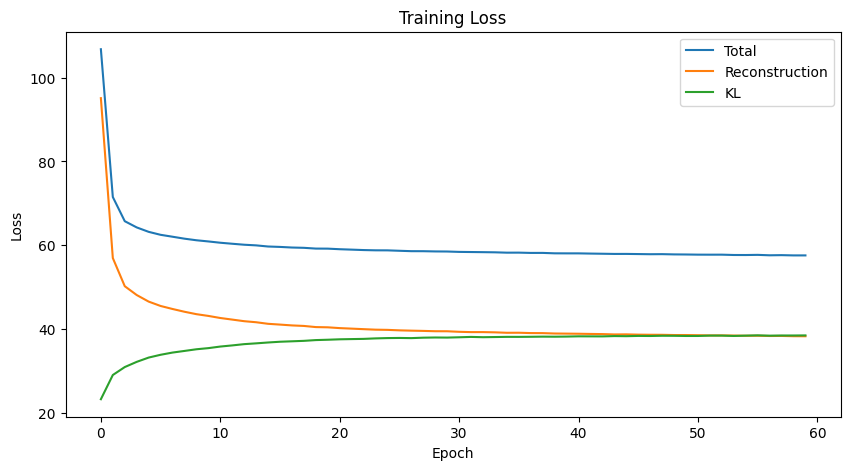

In [68]:
#plotting
plt.figure(figsize=(10,5))
plt.plot(train_losses, label="Total")
plt.plot(recon_losses, label="Reconstruction")
plt.plot(kl_losses, label="KL")
plt.legend()
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [69]:
torch.save(model.state_dict(), "m22aie202_vae_cifar.pth")

In [70]:
model.eval()

with torch.no_grad():
    z = torch.randn(16, latent_dim).to(device)
    samples = model.decoder(z).cpu()

In [71]:
grid = make_grid(samples, nrow=4)

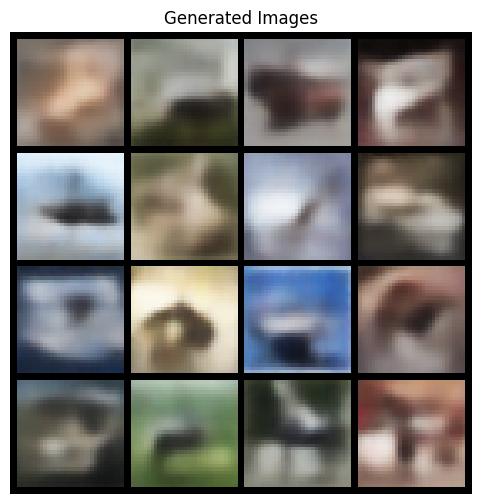

In [72]:
plt.figure(figsize=(6,6))
plt.imshow(np.transpose(grid, (1,2,0)))
plt.axis("off")
plt.title("Generated Images")
plt.show()